In [534]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#set your path
# s2p_dir = Path("/Users/suthardr/Desktop/plane0/")

# s2p_dir = Path("/Volumes/rkc_ramirezlab/Home/suthardr/Projects/2photon_menace/Astro2P_Pilot#5_2025Oct/PreProcess/jrgeco/10072025/932L/suite2p/plane0/")

#astrocyte 621N
s2p_dir = Path("/Users/suthardr/Desktop/621N_FC/suite2p/plane0/")

# #neuron 621N_
# s2p_dir_red = Path("/Users/suthardr/Desktop/621N_FC/suite2p_red/plane0/")

#load ya data
F      = np.load(s2p_dir / "F.npy")    #raw fluorescence (cells, indices)
Fneu   = np.load(s2p_dir / "Fneu.npy")       #neuropil (cells, indices)
iscell = np.load(s2p_dir / "iscell.npy", allow_pickle=True)
ops    = np.load(s2p_dir / "ops.npy", allow_pickle=True).item()

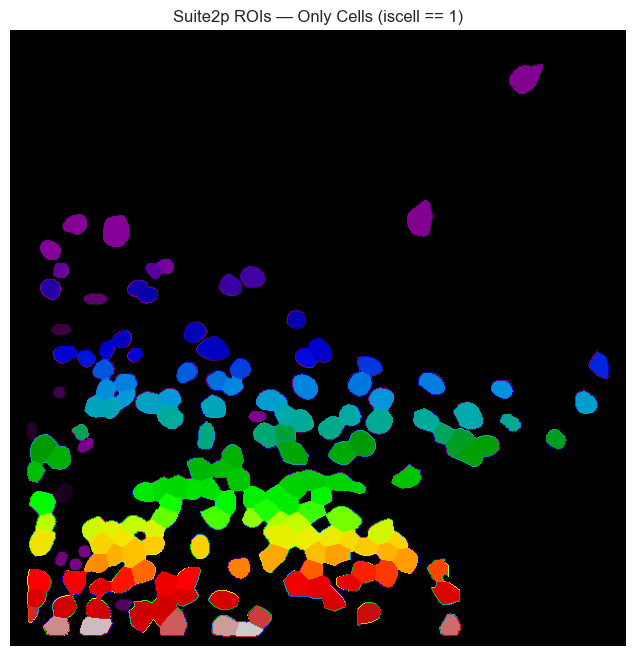

In [445]:
#plot mask
import numpy as np
import matplotlib.pyplot as plt

# Load Suite2p outputs
stat = np.load(s2p_dir / 'stat.npy', allow_pickle=True)

# Create cell mask (iscell is defined as Cell in Suite2p)
cell_mask = iscell[:, 0].astype(bool)

# Initialize blank image
im = np.zeros((ops['Ly'], ops['Lx']))

# Loop through only "cell" ROIs
cell_indices = np.where(cell_mask)[0]
for i, n in enumerate(cell_indices):
    ypix = stat[n]['ypix'][~stat[n]['overlap']]
    xpix = stat[n]['xpix'][~stat[n]['overlap']]
    im[ypix, xpix] = i + 1  # label each ROI
plt.figure(figsize=(8, 8))
plt.imshow(im, cmap='nipy_spectral')
plt.title('Suite2p ROIs — Only Cells (iscell == 1)')
plt.axis('off')
plt.show()

In [535]:
# Create a boolean mask for true cells
cell_mask = iscell[:, 0].astype(bool)

# Filter data
F_cells = F[cell_mask, :]
Fneu_cells = Fneu[cell_mask, :]

print(f"Original ROIs: {F.shape[0]}, Filtered cells: {F_cells.shape[0]}")

Original ROIs: 103, Filtered cells: 40


In [536]:
#correct neuropil
Fcorr = F_cells - 0.7 * Fneu_cells #corrected by neuropil
print(f"Shape of array: {Fcorr.shape}")

Shape of array: (40, 13115)


In [537]:
# --- Build timestamps that reflect alternating acquisition (absolute timebase) ---
n_frames = Fcorr.shape[1]

# Total frame rate before splitting (your case: 20.4 Hz total for R+G)
total_hz = 20.4
frame_period = 1.0 / total_hz          # time between consecutive total frames
per_channel_period = 2.0 * frame_period  # time between consecutive frames *of the same channel*

# If your channel was the **even** frames (e.g., Green first), offset_frames = 0
# If it was the **odd** frames (e.g., Red), offset_frames = 1
offset_frames = 1  # set to 1 if your channel starts on the 1st odd frame

offset_sec = offset_frames * frame_period
time = np.arange(n_frames) * per_channel_period + offset_sec

print(f"Total Hz: {total_hz}, offset: {offset_sec:.6f}s, duration: {time[-1]:.3f} s, n_frames: {n_frames}")


Total Hz: 20.4, offset: 0.049020s, duration: 1285.735 s, n_frames: 13115


In [538]:
from scipy.signal import savgol_filter

baseline = savgol_filter(Fcorr, 501, 3, axis=1)  # long window
dFF = (Fcorr - baseline) / baseline

In [539]:
# #convert to time
n_timepoints = 13115
duration_sec = 1285.735
#
time = np.linspace(0, duration_sec, n_timepoints)
time

array([0.00000000e+00, 9.80429312e-02, 1.96085862e-01, ...,
       1.28553891e+03, 1.28563696e+03, 1.28573500e+03])

In [540]:
from scipy.stats import zscore
import numpy as np

# Z-score across time for each cell (row)
dFF_norm = zscore(dFF, axis=1)

print(dFF.shape, dFF_norm.shape)

(40, 13115) (40, 13115)


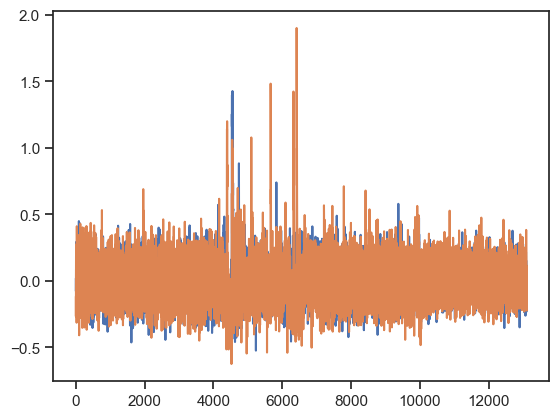

In [371]:
plt.plot(dFF[3:5, :].T)

In [47]:
tone_events = [120, 280, 440, 600, 760]
shock_events =[160, 320, 480, 640, 800]
delay_events = [140, 300, 460, 620, 780]

In [541]:
# events in full-frame indices
shock_frames_neurons = np.array([2179, 4365, 6550, 8735, 10925])
shock_frames_astros = np.array([2185, 4375, 6560, 8740, 10930])

#     #np.array([4379, 8751, 13129,  17494.6]) #15311.8,
# shock_frames = np.array([2179, 8751, 13129,  17494.6])
shock_times = shock_frames_astros / 10.2  # convert to seconds


In [542]:
shock_times

array([ 214.21568627,  428.92156863,  643.1372549 ,  856.8627451 ,
       1071.56862745])

In [543]:
tone_times = shock_times - 40
tone_times

array([ 174.21568627,  388.92156863,  603.1372549 ,  816.8627451 ,
       1031.56862745])

In [544]:
delay_times = shock_times - 20
delay_times

array([ 194.21568627,  408.92156863,  623.1372549 ,  836.8627451 ,
       1051.56862745])

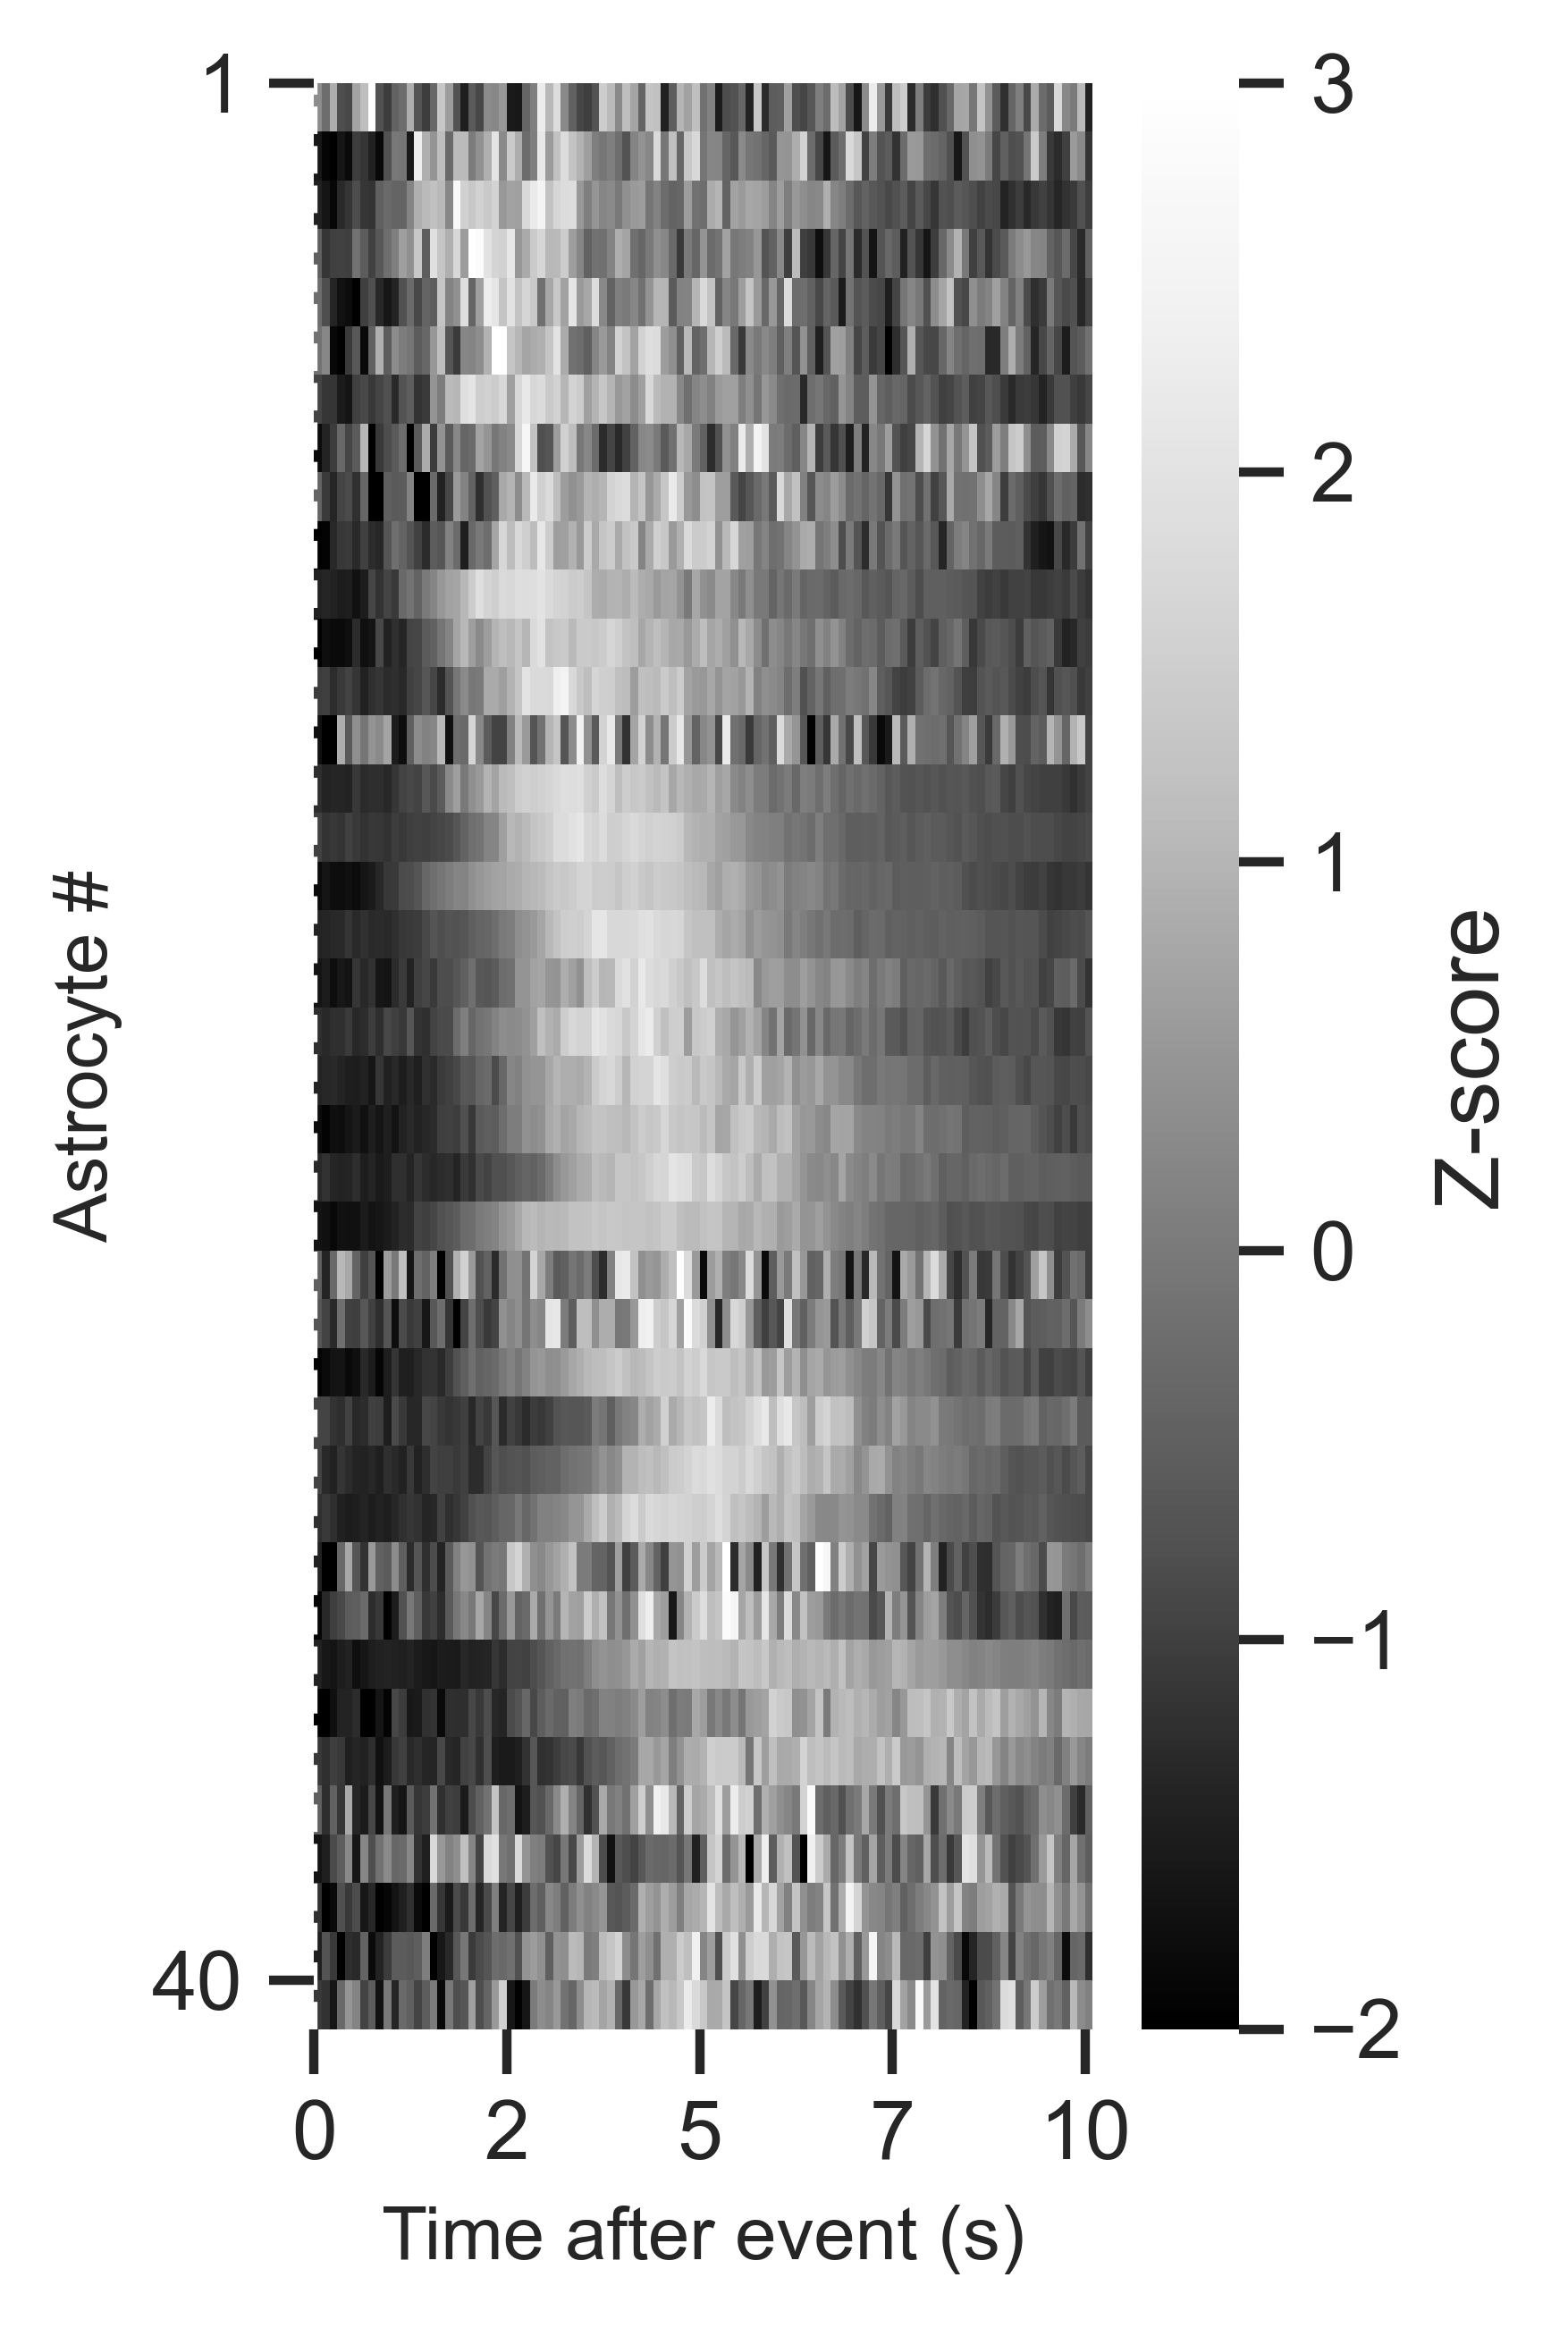

In [548]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def maxsort(arr):
    """Sort rows by the argmax of each row (ties keep numpy's default stability)."""
    return arr[np.argsort(np.argmax(arr, axis=1))]

def run_post_event_heatmap(
        traces,          # (T x N) or (N x T)
        timestamps,      # (T,) seconds, strictly increasing
        events,          # flat list/1D array of event times (seconds)
        save_path_prefix=None,
        window=15,       # seconds AFTER event onset
        vmin=-4, vmax=4
):
    # --- checks ---
    events = np.asarray(events, dtype=float).ravel()
    if events.size == 0:
        raise ValueError("`events` is empty. Provide at least one event time.")
    if timestamps.ndim != 1:
        raise ValueError("`timestamps` must be 1D.")
    if np.any(np.diff(timestamps) <= 0):
        raise ValueError("`timestamps` must be strictly increasing.")
    if traces.ndim != 2:
        raise ValueError("`traces` must be 2D (T x N) or (N x T).")

    # Ensure data is (N_cells x T)
    data_for_eta = traces.T if traces.shape[0] == timestamps.shape[0] else traces
    fs = 1.0 / np.median(np.diff(timestamps))
    n_points = int(window * fs)
    if n_points < 2:
        n_points = 2  # avoid degenerate interpolation
    t_rel = np.linspace(0, window, n_points)

    def event_window(signal, e):
        t_win = e + t_rel
        # only keep windows fully inside recording
        if t_win[-1] > timestamps[-1]:
            return None
        return np.interp(t_win, timestamps, signal)

    # Average ETA for each cell across all valid events
    all_cells = []
    for sig in data_for_eta:
        chunks = []
        for e in events:
            out = event_window(sig, e)
            if out is not None:
                chunks.append(out)
        if len(chunks):
            all_cells.append(np.mean(chunks, axis=0))
    if len(all_cells) == 0:
        raise ValueError("No valid event windows within the recording (try a smaller `window`).")

    eta_mean = np.vstack(all_cells)          # (N_cells x n_points)
    z = stats.zscore(eta_mean, axis=1, nan_policy='omit')
    z = np.nan_to_num(z, nan=0.0)

    z_sorted = maxsort(z)

    # --- Plot ---
    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial'})
    sns.set(style="ticks", font="Arial")
    fig, ax = plt.subplots(figsize=(3, 4.5), dpi=600)

    sns.heatmap(
        z_sorted, ax=ax, cmap='Greys_r', vmin=vmin, vmax=vmax,
        cbar=True, cbar_kws={'label': 'Z-score'},
        xticklabels=True, yticklabels=False, rasterized=True
    )

    # X-axis in seconds
    T = z_sorted.shape[1]
    xticks = np.linspace(0, T - 1, 5).astype(int)
    xticklabels = np.linspace(0, window, 5).astype(int)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=0)

    # Y-axis: first & last row
    n_cells = z_sorted.shape[0]
    ax.set_yticks([0, max(n_cells-1, 0)])
    ax.set_yticklabels(['1', str(n_cells)], rotation=0)

    # event onset at 0 s (left edge)
    ax.axvline(0, linestyle='--', color='white', linewidth=1)
    ax.set_xlabel('Time after event (s)', fontsize=10)
    ax.set_ylabel('Astrocyte #', fontsize=10)
    sns.despine(ax=ax, left=True, bottom=True)
    plt.tight_layout()

    out_path = None
    if save_path_prefix:
        out_path = f"{save_path_prefix}_event_heatmap.svg"
        fig.savefig(out_path, dpi=600, bbox_inches='tight')

    return fig, ax, out_path

fig_tone,  ax_tone,  _ = run_post_event_heatmap(traces=dFF, timestamps=time, events=shock_times,  window=10, vmin=-2, vmax=3, save_path_prefix="/Users/suthardr/Desktop/Sinai/astrocyte_shock_dFFZ_blackwhite")

# fig_delay, ax_delay, _ = run_post_event_heatmap(traces=dFF, timestamps=time, events=delay_times, window=20, vmin=-3, vmax=2, save_path_prefix="/Users/suthardr/Desktop/Sinai/neuron_trace_dFFZ")
# fig_shock, ax_shock, _ = run_post_event_heatmap(traces=dFF, timestamps=time, events=tone_times, window=20, vmin=-3, vmax=2, save_path_prefix="/Users/suthardr/Desktop/Sinai/neuron_tone_dFFZ")


In [514]:
shock_times

array([ 213.62745098,  427.94117647,  642.15686275,  856.37254902,
       1071.07843137])

In [485]:
import numpy as np
import scipy.interpolate
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Core ETA (event-triggered average) ----------
def compute_event_triggered_etas(
    traces,                # (T x N) or (N x T)
    timestamps,            # (T,) strictly increasing (seconds)
    events,                # list of event times [e1, e2, ...] OR per-cell list of lists
    window_pre=5.0,        # seconds BEFORE event
    window_post=10.0,      # seconds AFTER event
    interp_kind="linear",  # 'linear', 'cubic', etc.
    baseline_window=(-5.0, -3.0)  # seconds relative to event (within [-window_pre, window_post])
):
    # Ensure (N x T)
    if traces.ndim != 2:
        raise ValueError("`traces` must be 2D (T x N) or (N x T).")
    T, N_guess = traces.shape
    if traces.shape[0] == timestamps.shape[0]:     # (T x N)
        data = traces.T                            # -> (N x T)
    elif traces.shape[1] == timestamps.shape[0]:   # (N x T)
        data = traces                              # already (N x T)
    else:
        raise ValueError("`traces` first or second dimension must match len(timestamps).")

    if timestamps.ndim != 1 or np.any(np.diff(timestamps) <= 0):
        raise ValueError("`timestamps` must be a strictly increasing 1D array.")

    # Events: allow a single list for all cells or per-cell lists
    n_cells = data.shape[0]
    if isinstance(events, (list, np.ndarray)) and len(events) > 0 and not isinstance(events[0], (list, np.ndarray)):
        # same events for every cell
        per_cell_events = [np.asarray(events, dtype=float)] * n_cells
    else:
        # assume list of lists (one per cell)
        if len(events) != n_cells:
            raise ValueError("If you pass per-cell events, length must match number of cells.")
        per_cell_events = [np.asarray(ev, dtype=float) for ev in events]

    # Time axis for ETA
    t_rel = np.linspace(-window_pre, window_post, int(round((window_pre + window_post) / np.median(np.diff(timestamps)))))

    # Interpolator builder (per cell)
    def interp_fn(sig):
        return scipy.interpolate.interp1d(
            timestamps, sig, kind=interp_kind, bounds_error=False, fill_value="extrapolate"
        )

    etas_per_cell = []
    for i, sig in enumerate(data):
        f = interp_fn(sig)
        etas_this_cell = []
        for e in per_cell_events[i]:
            t_win = e + t_rel
            # Keep only windows fully inside the recording (optional but safer)
            if t_win[0] < timestamps[0] or t_win[-1] > timestamps[-1]:
                continue
            etas_this_cell.append(f(t_win))
        if len(etas_this_cell):
            per_event = np.vstack(etas_this_cell)  # (#events x #timepoints)
            etas_per_cell.append(per_event.mean(axis=0))  # average across events for this cell

    if len(etas_per_cell) == 0:
        raise ValueError("No valid event windows inside the recording. Try adjusting window_pre/window_post.")

    etas_per_cell = np.vstack(etas_per_cell)  # (Nc_valid x T_rel)

    # Baseline correction using baseline_window (relative to event)
    # Find indices inside t_rel that match the baseline window
    b0, b1 = baseline_window
    if b0 < -window_pre or b1 > window_post:
        raise ValueError("baseline_window must lie within [-window_pre, window_post].")
    bi = np.where((t_rel >= b0) & (t_rel <= b1))[0]
    if bi.size == 0:
        raise ValueError("baseline_window chosen too narrow; contains no samples.")
    baselines = etas_per_cell[:, bi].mean(axis=1, keepdims=True)
    etas_per_cell = etas_per_cell - baselines

    return t_rel, etas_per_cell  # per-cell, baseline-corrected ETAs


# ---------- Confidence intervals ----------
def t_confidence_interval(across_cells, alpha=0.05):
    """
    across_cells: (Nc x T)
    Returns low, high arrays shape (T,)
    """
    m = np.nanmean(across_cells, axis=0)
    s = stats.sem(across_cells, axis=0, nan_policy='omit')
    nc = across_cells.shape[0]
    if nc < 2:
        # degenerate; no CI
        return m, m
    tcrit = stats.t.ppf(1 - alpha/2.0, df=nc - 1)
    low = m - tcrit * s
    high = m + tcrit * s
    return low, high

def bootstrap_confidence_interval(across_cells, alpha=0.05, n_boot=1000, rng=None):
    """
    across_cells: (Nc x T)
    Nonparametric bootstrap over cells.
    """
    rng = np.random.default_rng(None if rng is None else rng)
    Nc, T = across_cells.shape
    if Nc < 2:
        m = np.nanmean(across_cells, axis=0)
        return m, m
    boots = np.empty((n_boot, T), dtype=float)
    for b in range(n_boot):
        idx = rng.integers(0, Nc, Nc)
        boots[b] = np.nanmean(across_cells[idx], axis=0)
    low = np.percentile(boots, 100*alpha/2.0, axis=0)
    high = np.percentile(boots, 100*(1 - alpha/2.0), axis=0)
    return low, high


# ---------- Significance detection (run-length above/below 0) ----------
def contiguous_sig_runs(ci_low, ci_high, min_duration_s, t_rel):
    """
    Mark segments where the CI excludes 0 for at least min_duration_s.
    Returns list of (start_index, end_index) inclusive indices.
    """
    dt = np.median(np.diff(t_rel))
    min_len = max(1, int(np.round(min_duration_s / dt)))

    # CI excludes zero if both bounds > 0 OR both < 0
    sig_mask = (ci_low > 0) | (ci_high < 0)

    runs = []
    start = None
    for i, v in enumerate(sig_mask):
        if v and start is None:
            start = i
        elif not v and start is not None:
            if i - start >= min_len:
                runs.append((start, i - 1))
            start = None
    if start is not None and (len(sig_mask) - start) >= min_len:
        runs.append((start, len(sig_mask) - 1))
    return runs


# ---------- High-level wrapper (no onep dependency) ----------
def eta_all(
    dFF, timestamps, events,
    window_pre=5.0, window_post=10.0,
    ci="tci", alpha=0.05, n_boot=1000,
    baseline_window=(-5.0, -3.0),
    sig_duration=10.0  # seconds
):
    """
    Computes per-cell baseline-corrected ETAs, group mean, CI, and significant segments.

    Parameters mirror your original, but with dFF/timestamps/events like your earlier code.
    """
    t_rel, across_eta_per_cell = compute_event_triggered_etas(
        dFF, timestamps, events,
        window_pre=window_pre, window_post=window_post,
        baseline_window=baseline_window
    )

    mean_trace = np.nanmean(across_eta_per_cell, axis=0)

    if ci == "tci":
        lo, hi = t_confidence_interval(across_eta_per_cell, alpha=alpha)
    elif ci == "bci":
        lo, hi = bootstrap_confidence_interval(across_eta_per_cell, alpha=alpha, n_boot=n_boot)
    else:
        raise ValueError("ci must be 'tci' or 'bci'")

    sig_runs = contiguous_sig_runs(lo, hi, min_duration_s=sig_duration, t_rel=t_rel)
    return t_rel, mean_trace, (lo, hi), sig_runs, across_eta_per_cell


# ---------- Plotting helper ----------
def plot_eta_all(
    dFF, timestamps, events,
    title="", save_path=None,
    window_pre=5.0, window_post=10.0,
    ci="tci", alpha=0.05, n_boot=1000,
    baseline_window=(-5.0, -3.0),
    sig_duration=10.0,
    line_kwargs=None, fill_kwargs=None
):
    """
    Plot ETA mean ± CI with significance bars, compatible with your previous API.
    """
    if line_kwargs is None:
        line_kwargs = dict(color="#B39BC8", linewidth=1.5)
    if fill_kwargs is None:
        fill_kwargs = dict(alpha=0.25)

    t_rel, mean_trace, (lo, hi), sig_runs, across_eta_per_cell = eta_all(
        dFF, timestamps, events,
        window_pre=window_pre, window_post=window_post,
        ci=ci, alpha=alpha, n_boot=n_boot,
        baseline_window=baseline_window, sig_duration=sig_duration
    )

    plt.rcParams.update({'font.size': 8})
    sns.set(style="ticks", font="Arial")

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    ax.plot(t_rel, mean_trace, **line_kwargs)
    ax.fill_between(t_rel, lo, hi, **fill_kwargs)

    # Event at t=0
    ax.axvline(x=0, color='black', linestyle='--')
    ax.text(0, ax.get_ylim()[1] * 1.02, 'Event Onset', ha='center', va='bottom', fontsize=8, fontname='Arial')

    ax.set_ylabel(r"ΔF/F", fontsize=10, fontname='Arial', labelpad=15)
    ax.set_xlabel('Time (s)', fontsize=10, fontname='Arial')
    ax.set_title(title, fontsize=10, pad=10, fontname='Arial')
    ax.tick_params(labelsize=8)
    sns.despine(ax=ax)
    plt.tight_layout(pad=3)

    # Significance bars along the top
    y_marker = ax.get_ylim()[1] * 0.97
    for s, e in sig_runs:
        ax.hlines(y=y_marker, xmin=t_rel[s], xmax=t_rel[e], linewidth=1, color='black')

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')

    return fig, ax, (t_rel, mean_trace, (lo, hi), sig_runs, across_eta_per_cell)


(166, 153)


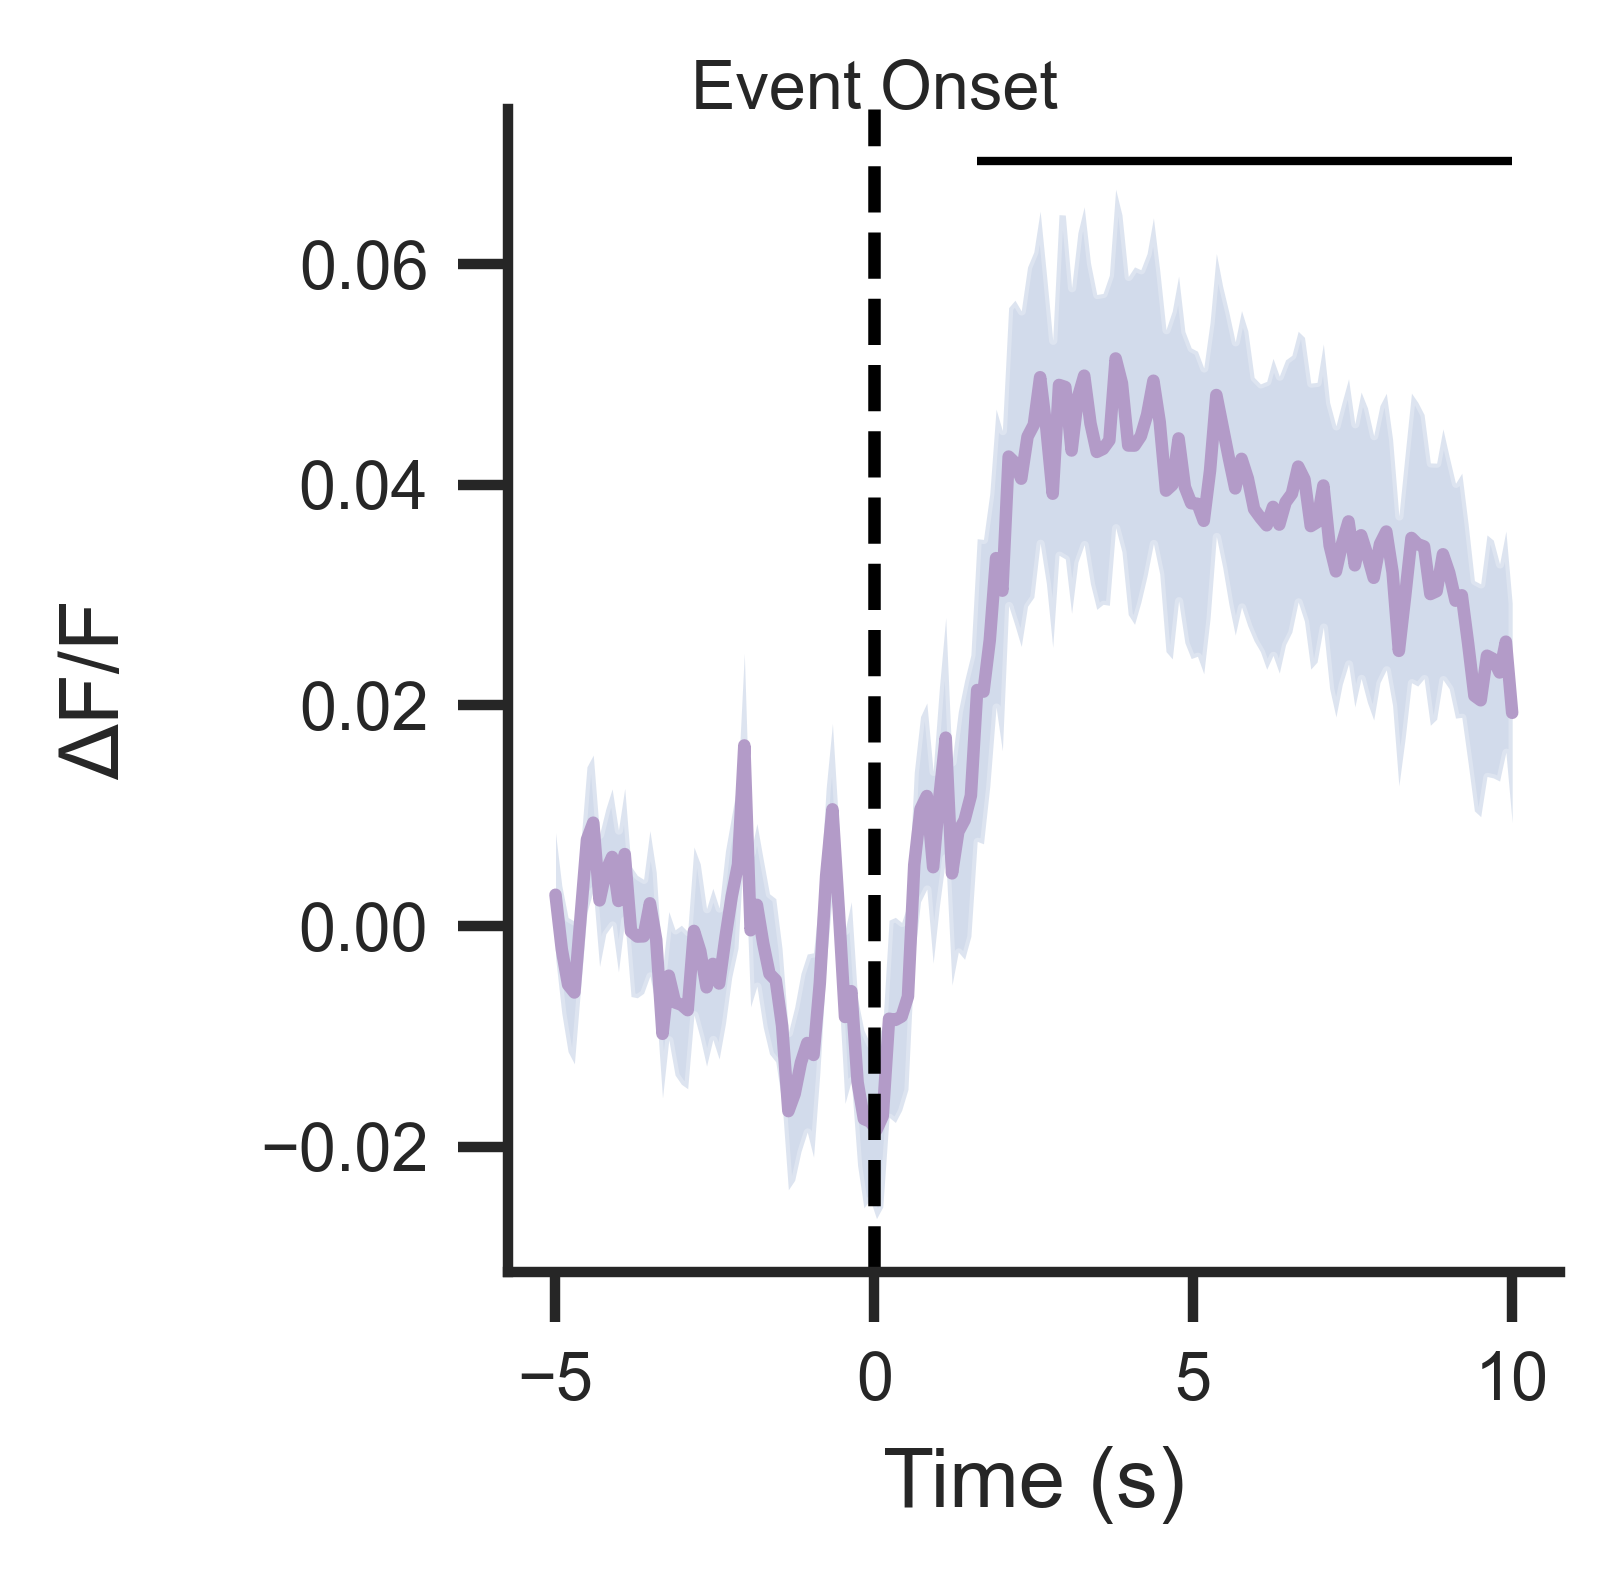

In [490]:
# Call the function and unpack all returned outputs
fig, ax, (t_rel, mean_trace, ci_bounds, sig_runs, across_eta_per_cell) = plot_eta_all(
    dFF,
    time,
    events=shock_times,
    window_pre=5.0,
    window_post=10.0,
    ci='tci',
    sig_duration=1.0,
    save_path="/Users/suthardr/Desktop/Sinai/neuron_avg_shock_10s.svg"
)

# Now you can access the per-cell data directly
print(across_eta_per_cell.shape)



In [497]:
delay_times

array([ 193.62745098,  407.94117647,  622.15686275,  836.37254902,
       1051.07843137])

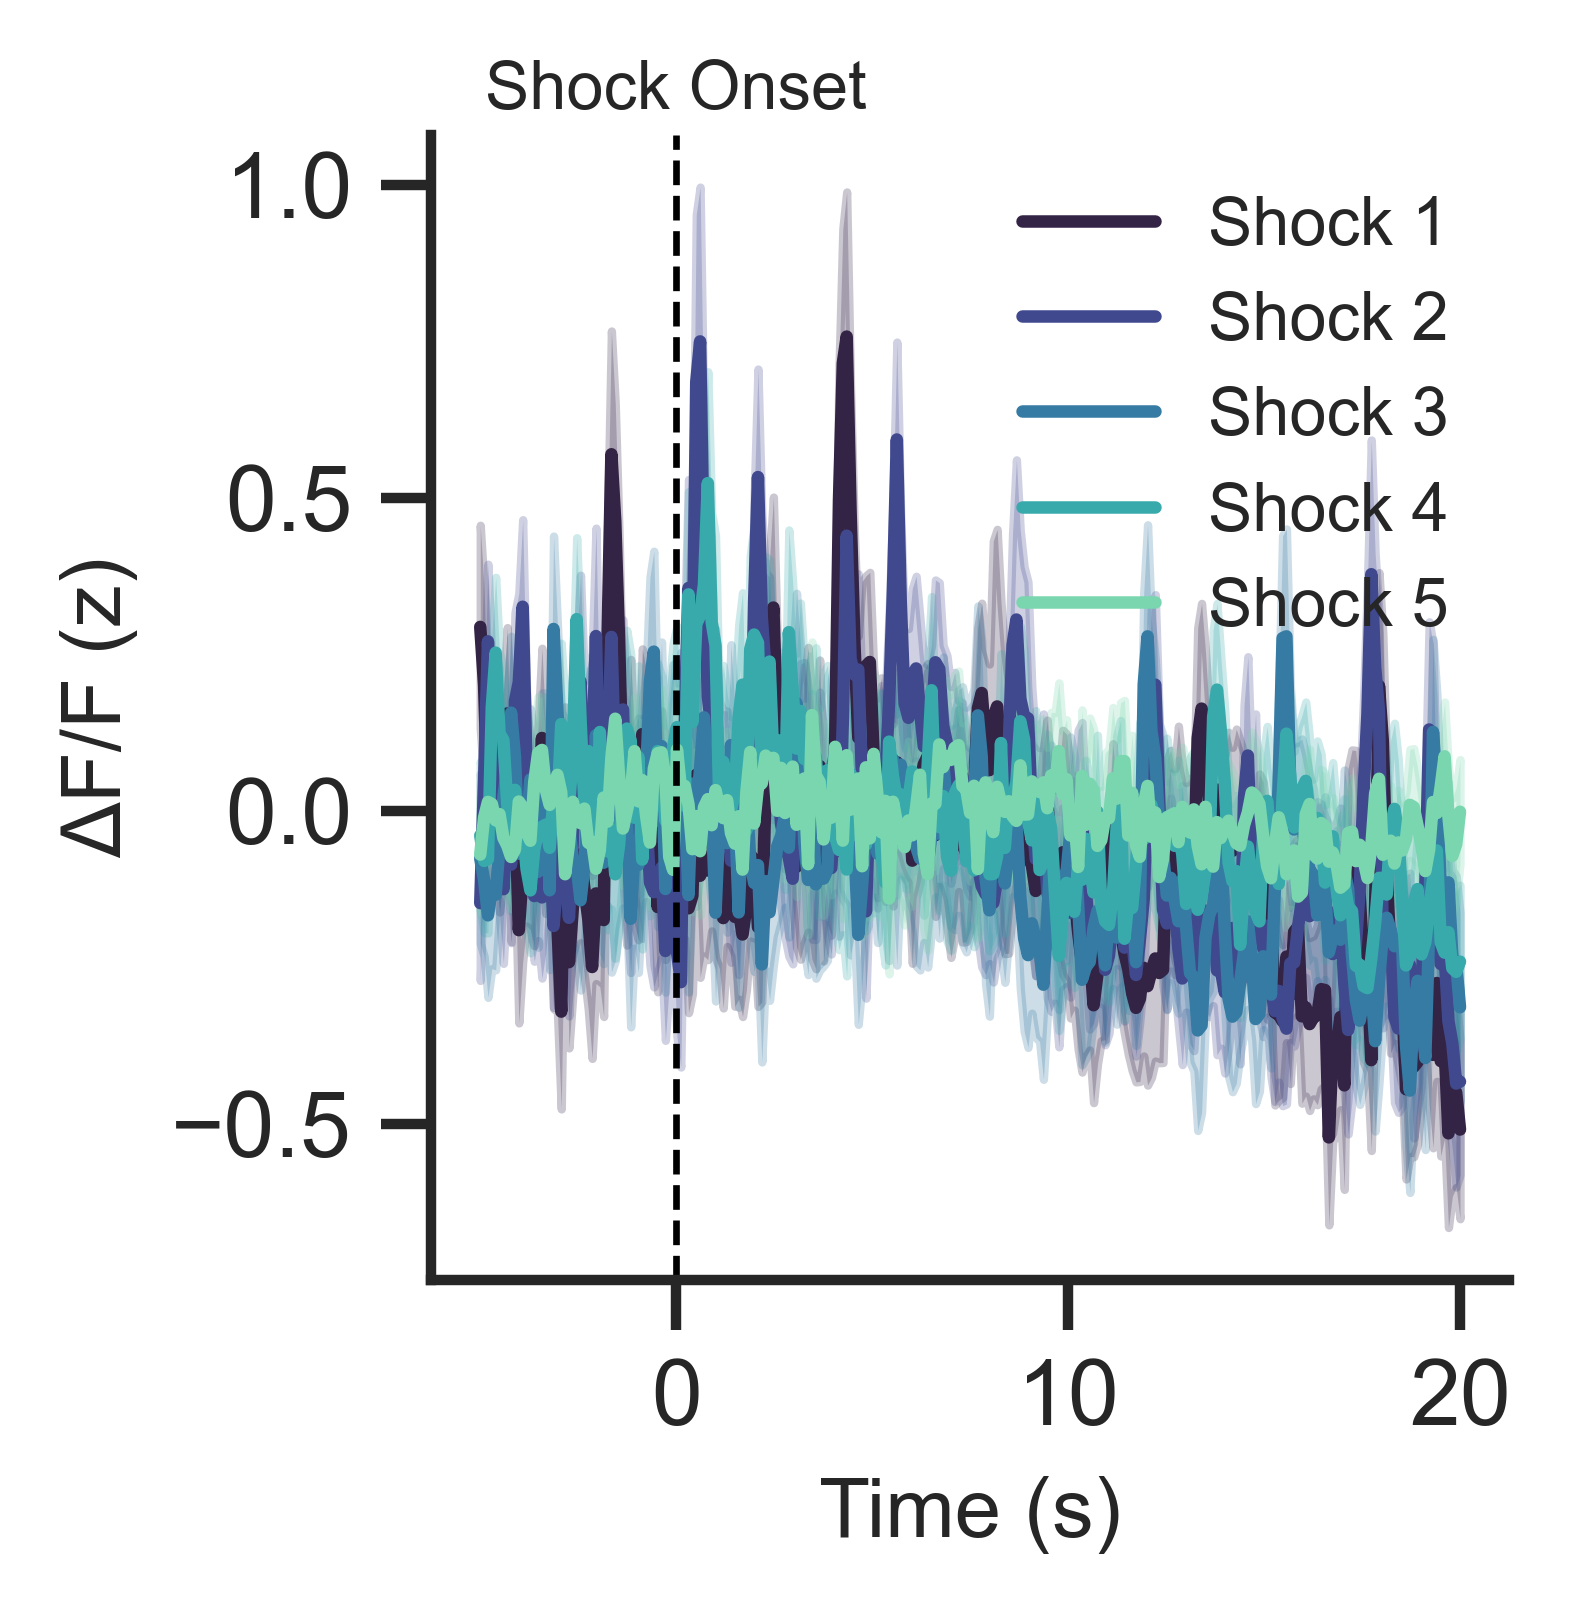

In [500]:

# shock_event_sets = [
#     [214.656863],
#     [428.970588],
#     [643.578431],
#      [857.578431]
# ]

shock_event_sets = [[ 213.62745098],  [427.94117647],  [642.15686275],  [856.37254902],
       [1071.07843137]]

#tone_event_sets = [[173.62745098],  [387.94117647],  [602.15686275],  [816.37254902],
       #[1031.07843137]]

tone_event_sets = [[193.62745098],  [407.94117647],  [622.15686275],  [836.37254902],
       [1051.07843137]]

# Define colors for each block
colors = sns.color_palette("mako", n_colors=len(tone_event_sets))

# Create one figure for all
plt.rcParams.update({'font.size': 8})
sns.set(style="ticks", font="Arial")
fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)

# Loop through each set
for i, (tone_times, color) in enumerate(zip(tone_event_sets, colors), start=1):
    t_rel, mean_trace, (lo, hi), sig_runs, _ = eta_all(
        dFF_norm, time, tone_times,
        window_pre=5.0, window_post=20.0,
        ci='tci', sig_duration=2.0
    )

    # Plot mean ± CI
    ax.plot(t_rel, mean_trace, color=color, lw=1.5, label=f'Shock {i}')
    ax.fill_between(t_rel, lo, hi, color=color, alpha=0.25)

# --- Formatting ---
ax.axvline(0, color='black', linestyle='--', lw=0.8)
ax.text(0, ax.get_ylim()[1]*1.02, 'Shock Onset', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Time (s)', fontsize=10)
ax.set_ylabel(r'ΔF/F (z)', fontsize=10)
ax.legend(frameon=False, fontsize=8)
sns.despine(ax=ax)
plt.tight_layout(pad=3)
fig.savefig("/Users/suthardr/Desktop/Sinai/neuron_delay_each_dFFZ_20s.svg")
plt.show()


In [501]:
import numpy as np
import scipy.stats as stats

def compute_per_event_windows(
    traces, timestamps, events, window_pre=5.0, window_post=10.0, interp_kind="linear"
):
    """
    Return per-cell, per-event windows (baseline NOT removed yet):
    list of arrays: per_cell_events[i] -> shape (#events_i x T_rel)
    also returns t_rel (shared across cells).
    """
    # Ensure (N x T)
    if traces.shape[0] == timestamps.shape[0]:   # (T x N)
        data = traces.T
    elif traces.shape[1] == timestamps.shape[0]: # (N x T)
        data = traces
    else:
        raise ValueError("One dimension of `traces` must match len(timestamps).")

    # events as per-cell lists or shared list
    n_cells = data.shape[0]
    if isinstance(events, (list, np.ndarray)) and len(events) > 0 and not isinstance(events[0], (list, np.ndarray)):
        per_cell_events = [np.asarray(events, float)] * n_cells
    else:
        if len(events) != n_cells:
            raise ValueError("Per-cell events provided but length != #cells.")
        per_cell_events = [np.asarray(ev, float) for ev in events]

    dt = np.median(np.diff(timestamps))
    n_points = int(round((window_pre + window_post) / dt))
    t_rel = np.linspace(-window_pre, window_post, n_points)

    from scipy.interpolate import interp1d
    per_cell_windows = []
    for sig, evs in zip(data, per_cell_events):
        f = interp1d(timestamps, sig, kind=interp_kind, bounds_error=False, fill_value="extrapolate")
        cell_chunks = []
        for e in evs:
            t_win = e + t_rel
            if t_win[0] < timestamps[0] or t_win[-1] > timestamps[-1]:
                continue
            cell_chunks.append(f(t_win))
        per_cell_windows.append(np.vstack(cell_chunks) if len(cell_chunks) else np.empty((0, n_points)))
    return t_rel, per_cell_windows


def filter_responsive_cells(
    dFF, timestamps, events,
    method="z",                 # "z" or "ttest"
    window_pre=5.0, window_post=10.0,
    baseline_window=(-5.0, -3.0),
    response_window=(0.0, 5.0),
    z_threshold=2.0,           # for method="z"
    p_threshold=0.05,          # for method="ttest" (before FDR)
    fdr_q=0.05,                # FDR target
    min_duration_s=0.0         # optional: require response above threshold for >= this duration (z method)
):
    """
    Returns:
      responsive_idx: np.array of selected cell indices
      metrics: dict with per-cell metrics (peak_z, p_value, etc.)
    """
    t_rel, per_cell_windows = compute_per_event_windows(
        dFF, timestamps, events, window_pre=window_pre, window_post=window_post
    )
    # indices for baseline/response windows
    bi = np.where((t_rel >= baseline_window[0]) & (t_rel <= baseline_window[1]))[0]
    ri = np.where((t_rel >= response_window[0]) & (t_rel <= response_window[1]))[0]
    if bi.size == 0 or ri.size == 0:
        raise ValueError("Baseline/response windows must contain samples.")

    # Compute per-cell Z across events (baseline-correct each event)
    peak_z_list = []
    dur_pass_list = []
    pvals = []

    for chunks in per_cell_windows:
        if chunks.size == 0:
            peak_z_list.append(np.nan)
            dur_pass_list.append(False)
            pvals.append(1.0)
            continue

        # baseline-correct each event by its own baseline mean
        base = chunks[:, bi].mean(axis=1, keepdims=True)
        chunks_bc = chunks - base

        # --- z method: compute per-cell mean response and z-score across timepoints (per event mean first)
        # Average across events to get ETA for this cell
        eta = chunks_bc.mean(axis=0)

        # Z-score eta within the cell (relative to its own mean/std across ALL t_rel)
        # or use baseline std only (often better). We'll use baseline std:
        mu_b = eta[bi].mean()
        sd_b = eta[bi].std(ddof=1) if bi.size > 1 else np.nan
        if not np.isfinite(sd_b) or sd_b == 0:
            z_eta = np.zeros_like(eta)
        else:
            z_eta = (eta - mu_b) / sd_b

        # Peak z & optional duration criterion within response window
        z_resp = z_eta[ri]
        peak_z = np.nanmax(z_resp) if z_resp.size else np.nan
        peak_z_list.append(peak_z)

        if min_duration_s > 0 and np.isfinite(peak_z):
            dt = np.median(np.diff(t_rel))
            min_len = max(1, int(round(min_duration_s / dt)))
            above = z_resp >= z_threshold
            # run-length check
            run_ok = False
            run = 0
            for v in above:
                run = run + 1 if v else 0
                if run >= min_len:
                    run_ok = True
                    break
            dur_pass_list.append(run_ok)
        else:
            dur_pass_list.append(True)

        # --- t-test method: pool samples from baseline vs response across events (per event, per time sample)
        # Flatten across events and time bins in each window
        base_samples = chunks_bc[:, bi].reshape(-1)
        resp_samples = chunks_bc[:, ri].reshape(-1)
        if base_samples.size > 1 and resp_samples.size > 1:
            tt = stats.ttest_ind(resp_samples, base_samples, equal_var=False)
            pvals.append(tt.pvalue if np.isfinite(tt.pvalue) else 1.0)
        else:
            pvals.append(1.0)

    peak_z_arr = np.asarray(peak_z_list)
    pvals = np.asarray(pvals)

    # FDR correction for t-test
    def fdr_bh(p, q):
        p = np.asarray(p)
        m = np.sum(~np.isnan(p))
        order = np.argsort(p)
        ranks = np.empty_like(order)
        ranks[order] = np.arange(1, len(p)+1)
        thresh = q * ranks / m
        passed = p <= thresh
        # ensure monotonicity
        if not np.any(passed):
            return np.zeros_like(p, dtype=bool)
        kmax = np.max(np.where(passed))
        return p <= thresh[kmax]

    metrics = {"peak_z": peak_z_arr, "p_value": pvals}

    if method == "z":
        pass_mask = (peak_z_arr >= z_threshold) & np.asarray(dur_pass_list)
    elif method == "ttest":
        # FDR on pvals
        ok = np.isfinite(pvals)
        fdr_mask = np.zeros_like(pvals, dtype=bool)
        if ok.any():
            fdr_mask[ok] = fdr_bh(pvals[ok], fdr_q)
        pass_mask = fdr_mask & np.isfinite(pvals)
    else:
        raise ValueError("method must be 'z' or 'ttest'")

    responsive_idx = np.where(pass_mask)[0]
    return responsive_idx, metrics, (t_rel, per_cell_windows)


In [502]:

# Filter using z-threshold (peak z ≥ 2 in 0–5 s; require ≥0.5 s above threshold)
idx_z, metrics_z, _ = filter_responsive_cells(
    dFF, time, shock_times,
    method="z",
    window_pre=5.0, window_post=15.0,
    baseline_window=(-5, -3),
    response_window=(0, 10),
    z_threshold=2.0,
    min_duration_s=0.5
)

# Or filter using t-test + FDR (q=0.05)
idx_t, metrics_t, _ = filter_responsive_cells(
    dFF, time, shock_times,
    method="ttest",
    window_pre=5.0, window_post=15.0,
    baseline_window=(-5, -3),
    response_window=(0, 10),
    p_threshold=0.05,
    fdr_q=0.05
)

print("Responsive (z):", idx_z)
print("Responsive (ttest FDR):", idx_t)


Responsive (z): [ 12  13  20  29  52  57  74  76  80  83 104 108 111 145 156]
Responsive (ttest FDR): [  0   1   2  12  13  16  20  26  29  38  45  47  52  57  61  74  76  80
  93  98 104 115 117 141 142 145 153 158]


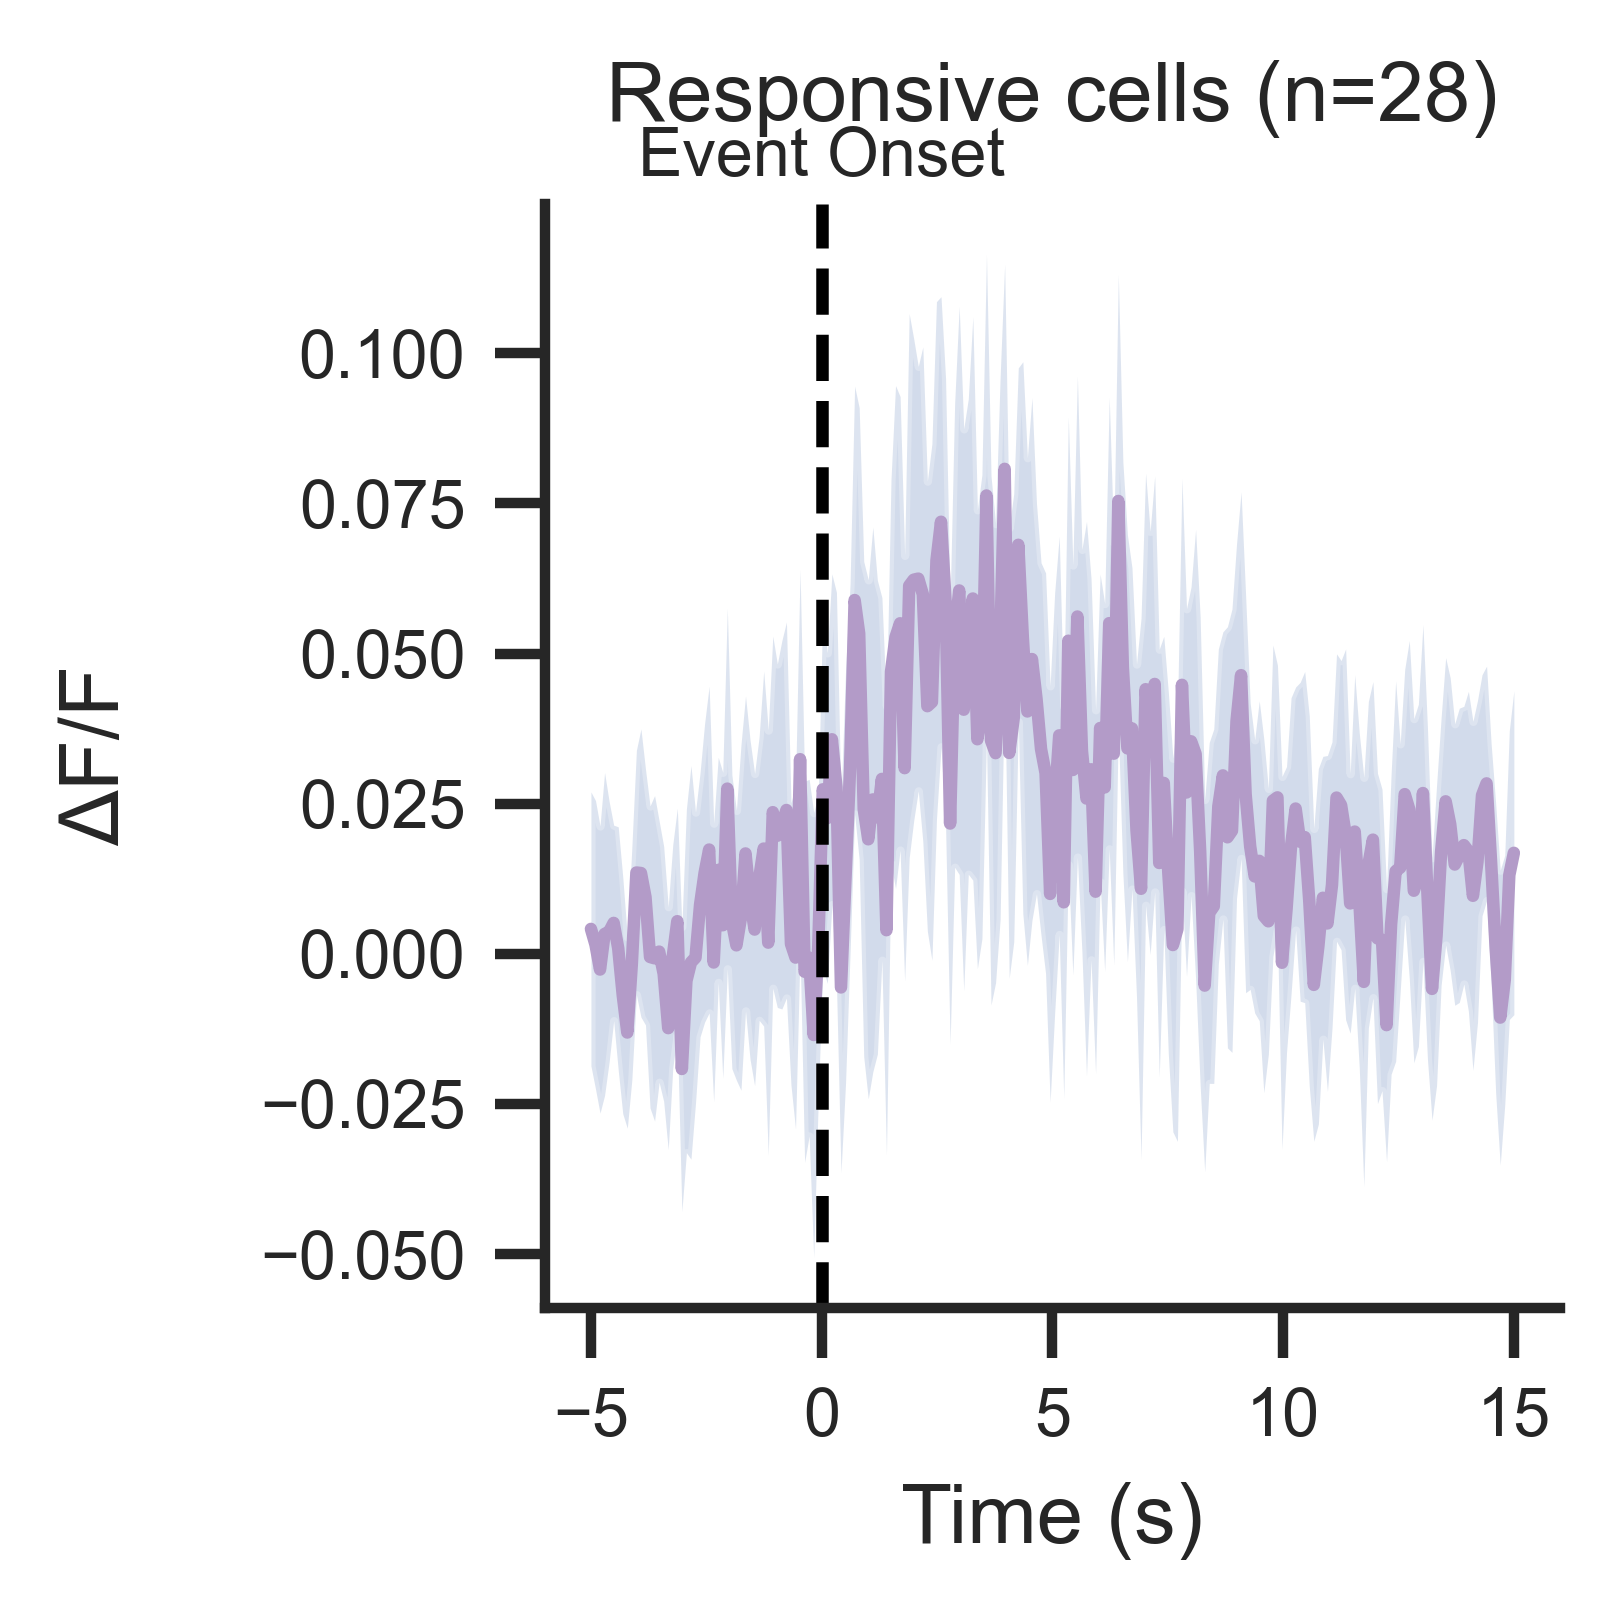

In [505]:
# Example: plot ETA of only z-responsive cells for these events
subset = dFF[:, idx_t] if dFF.shape[0] == len(time) else dFF[idx_t, :]
fig, ax, _ = plot_eta_all(
    subset, time, shock_times,
    window_pre=5.0, window_post=15.0,
    ci='tci', sig_duration=10.0,
    title=f"Responsive cells (n={len(idx_t)})"
)


2025-11-05 14:05:43,052 [INFO] normalizing data across axis=1
2025-11-05 14:05:43,068 [INFO] projecting out mean along axis=0
2025-11-05 14:05:43,081 [INFO] data normalized, 0.03sec
2025-11-05 14:05:43,082 [INFO] sorting activity: 166 valid samples by 13114 timepoints
2025-11-05 14:05:47,200 [INFO] n_PCs = 166 computed, 4.15sec
2025-11-05 14:05:47,449 [INFO] 78 clusters computed, time 4.40sec


/Users/suthardr/Documents/GitHub/CalciumKit/venv/lib/python3.9/site-packages/rastermap/cluster.py:138: UserWarning: found fewer than half the n_clusters that the user specified, rerunning with random initialization
  warnings.warn(
/Users/suthardr/Documents/GitHub/CalciumKit/venv/lib/python3.9/site-packages/rastermap/cluster.py:148: UserWarning: found fewer clusters than user specified, try reducing n_clusters and/or reduce n_splits and/or increase n_PCs
  warnings.warn(


2025-11-05 14:05:51,935 [INFO] clusters sorted, time 8.88sec
2025-11-05 14:05:51,981 [INFO] clusters upsampled, time 8.93sec
2025-11-05 14:05:52,001 [INFO] rastermap complete, time 8.95sec


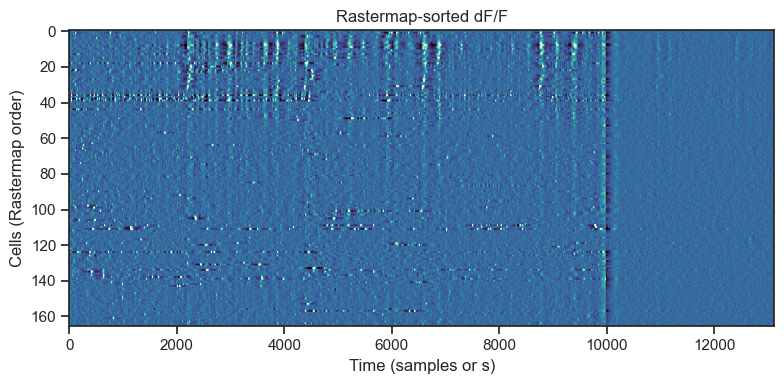

In [506]:
import numpy as np
import inspect
from rastermap import Rastermap
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def make_rastermap(**prefs):
    """
    Create a Rastermap model compatible with multiple versions.
    You can override defaults via **prefs.
    """
    # Discover accepted parameters on this install
    sig = inspect.signature(Rastermap)
    have = set(sig.parameters.keys())

    # Three known families of signatures (choose first that fits)
    if {"n_clusters", "n_PCs", "locality", "time_lag_window"}.issubset(have):
        kwargs = dict(n_clusters=100, n_PCs=200, locality=0.2,
                      time_lag_window=0, grid_upsample=10)
    elif {"n_X", "alpha", "n_PCs"}.issubset(have):
        kwargs = dict(n_X=100, alpha=1.0, n_PCs=200, timelag=0)
    elif {"n_components", "n_neighbors", "n_pcs"}.issubset(have):
        kwargs = dict(n_components=1, n_neighbors=200, n_pcs=100,
                      n_epochs=500, learning_rate=1.0, random_state=0)
    else:
        # Fall back to no-arg init; user can pass prefs explicitly
        kwargs = {}

    # Allow user overrides
    kwargs.update(prefs)
    return Rastermap(**kwargs)

# --- Use Rastermap to find data-driven events, then plot ETA with your function ---
# Ensure data is (cells x time)
data_ct = dFF.T if dFF.shape[0] == len(time) else dFF

# 1) Fit Rastermap with the compatible signature for your install
rm = make_rastermap()
rm.fit(data_ct)

# 2) Reorder cells by the 1D embedding
order = np.argsort(rm.embedding[:, 0]) if rm.embedding.ndim == 2 else np.argsort(rm.embedding)
data_sorted = data_ct[order]

# Optional: visualize reordered raster
plt.figure(figsize=(8, 4))
vmin, vmax = np.percentile(data_sorted, [1, 99])
plt.imshow(data_sorted, aspect='auto', cmap='mako', vmin=vmin, vmax=vmax)
plt.xlabel('Time (samples or s)')
plt.ylabel('Cells (Rastermap order)')
plt.title('Rastermap-sorted dF/F')
plt.tight_layout()
plt.show()


Indices of first 40 Rastermap-sorted cells:
[110 113 121 117 125 106  29 156  74  20  13 105  12  34  97 145  72 102
  93  90  99  15  81  60 101  57 104  38  55  54  62  80  52 158 151 153
 140 144  31 163]


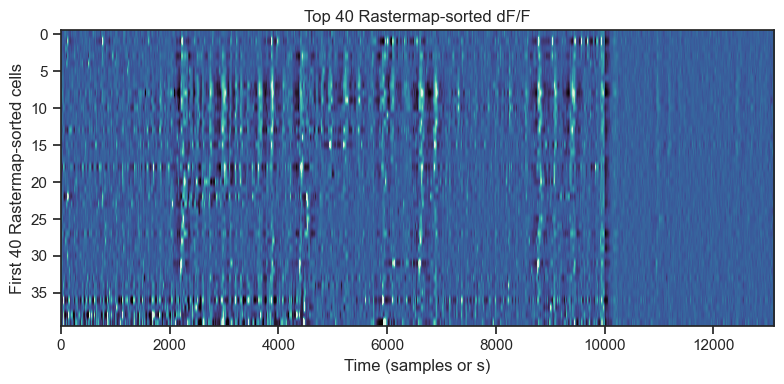

In [507]:
# 2) Reorder cells by the 1D embedding
order = np.argsort(rm.embedding[:, 0]) if rm.embedding.ndim == 2 else np.argsort(rm.embedding)
data_sorted = data_ct[order]

# --- Grab the first 40 Rastermap-sorted cells ---
first40 = data_sorted[:40, :]
first40_order = order[:40]  # indices of the original cells

print(f"Indices of first 40 Rastermap-sorted cells:\n{first40_order}")

# --- Optional: visualize only those 40 ---
import matplotlib.pyplot as plt
vmin, vmax = np.percentile(first40, [1, 99])
plt.figure(figsize=(8, 4))
plt.imshow(first40, aspect='auto', cmap='mako', vmin=vmin, vmax=vmax)
plt.xlabel('Time (samples or s)')
plt.ylabel('First 40 Rastermap-sorted cells')
plt.title('Top 40 Rastermap-sorted dF/F')
plt.tight_layout()
plt.show()


(40, 204)


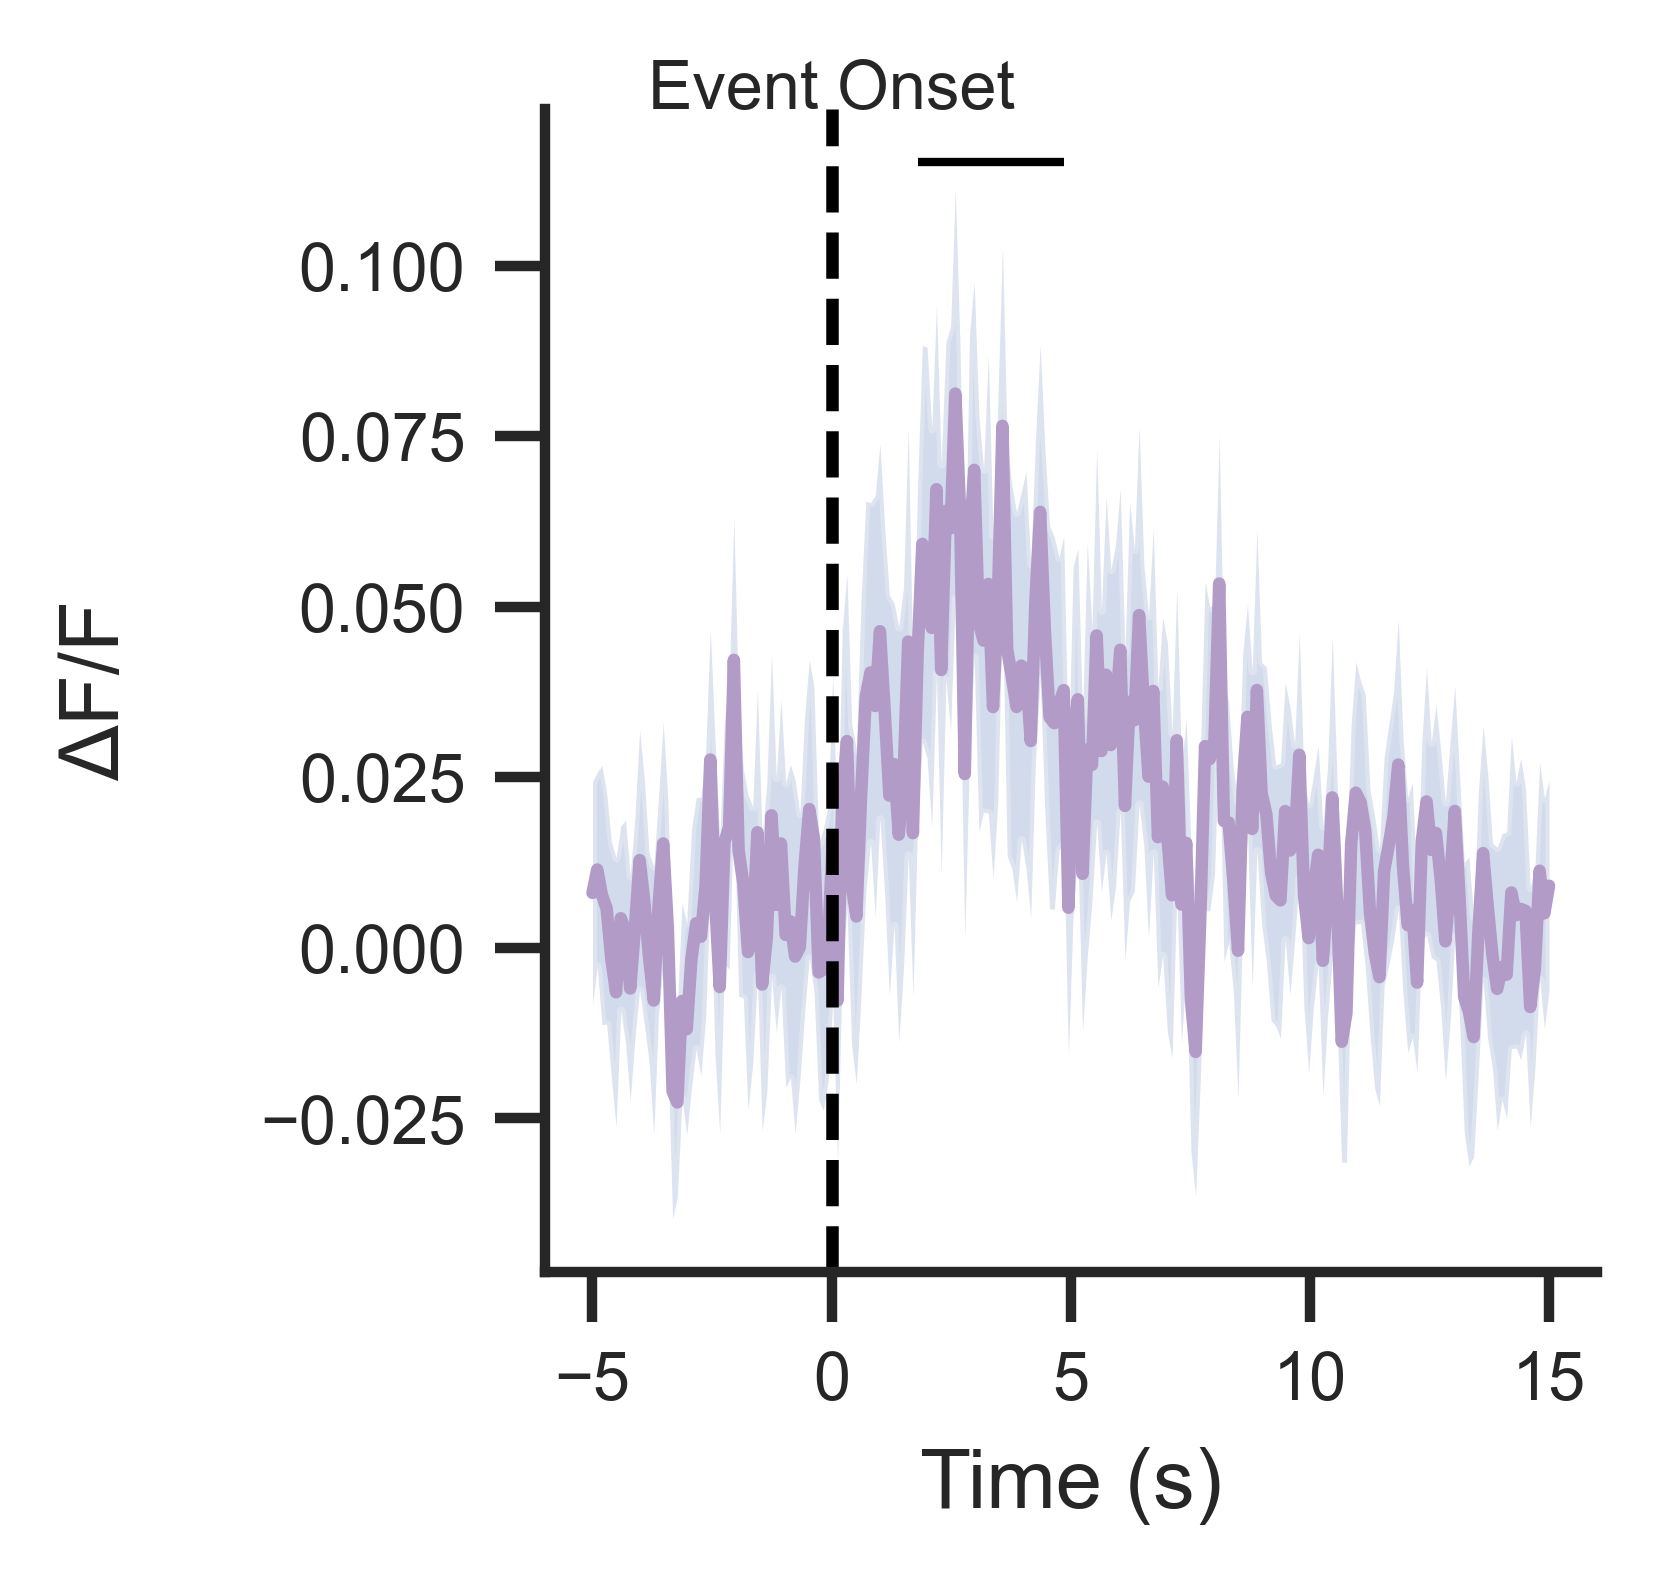

In [508]:
subset_dFF = dFF[:, first40_order] if dFF.shape[0] == len(time) else dFF[first40_order, :]
# Call the function and unpack all returned outputs
fig, ax, (t_rel, mean_trace, ci_bounds, sig_runs, across_eta_per_cell) = plot_eta_all(
    subset_dFF,
    time,
    events=shock_times,
    window_pre=5.0,
    window_post=15.0,
    ci='tci',
    sig_duration=1.0
    #save_path='/Users/suthardr/Desktop/eta_all.svg'
)

# Now you can access the per-cell data directly
print(across_eta_per_cell.shape)



IndexError: index 20 is out of bounds for axis 0 with size 20

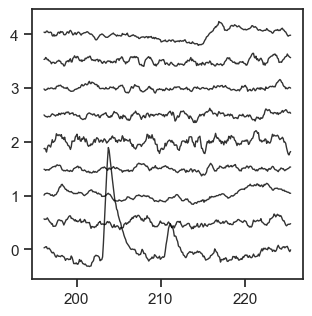

In [360]:
import numpy as np

def smooth(y, window=5):
    return np.convolve(y, np.ones(window)/window, mode='same')

offset = 0.5
fig, ax = plt.subplots(figsize=(3.5, 3.5))

cells_to_plot = [0, 1, 2, 3, 4, 5, 9, 12, 18, 20]
for j, i in enumerate(cells_to_plot):
    y = smooth(subset_dFF[i, 2000:2300], window=7)  # ← adjust window for smoothness
    ax.plot(time[2000:2300], y + j * offset, color='black', alpha=0.8, linewidth=1)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Cell #')
plt.tight_layout()
plt.show()

